In [0]:
# Using Spark to load the file
df1 = spark.read.format("csv").option("header", "true").load("dbfs:/FileStore/shared_uploads/tphan23@gmu.edu/bridge_data_final-1.csv")
df1 = df1.dropna()
display(df1)

State_Code,State_Name,Structure_Number,Owner_Agency,County_Code,County_Name,Place_Code,InfoBridge_Place_Code,InfoBridge_Place_Name,Year_Built,Average_Daily_Traffic,Main_Span_Material,Main_Span_Design,Span_Count,Length_ft,Features_Intersected,Facility_Carried,Bridge_Condition,Bridge_Age,Deck_Area_sqft
36,New York,1077870,State Highway Agency,59,Nassau County,34000,53264,North Merrick CDP,1936,7879,Steel,Stringer/Multi-beam or Girder,1,29.9,EAST MEADOW BROOK,JERUSALEM AVENUE,Fair,88,2811.2
36,New York,1059569,State Highway Agency,59,Nassau County,34000,63506,Roosevelt CDP,1935,0,Concrete,Arch - Deck,1,78.1,RTE 908M,MSP-SSP CONNECTOR,Good,89,4534.4
36,New York,1520289,State Highway Agency,59,Nassau County,34000,63506,Roosevelt CDP,1956,0,Concrete,Arch - Deck,1,91.9,RTE 908M,SSP-MSP CONNECTOR,Fair,68,5334.6
36,New York,1059239,State Highway Agency,59,Nassau County,34000,76089,Uniondale CDP,1955,17753,Concrete Continuous,Frame,2,98.1,"908E908E03011072, RTE 90",JERUSALEM AVENUE,Good,69,7563.3
36,New York,1057100,State Highway Agency,59,Nassau County,56000,38539,Jericho CDP,1990,1860,Prestressed Concrete,Box Beam or Girders - Multiple,1,68.9,RTE I495,RTE 906A,Fair,34,2848.1
36,New York,1049179,State Highway Agency,59,Nassau County,56000,38539,Jericho CDP,1961,141478,Steel,Stringer/Multi-beam or Girder,1,75.1,LIEWB CONN TO NSP,RTE I495,Fair,63,11215.4
36,New York,1058590,State Highway Agency,59,Nassau County,56000,34374,Hicksville CDP,1938,7139,Concrete,Arch - Deck,1,84.0,"908T908T03011110, RTE 90",STEWART AVENUE,Fair,86,4464.0
36,New York,3300200,County Highway Agency,59,Nassau County,34000,4143,Baldwin CDP,1956,21086,Concrete,Culvert,2,23.0,MILBURN CREEK,MERRICK ROAD,Good,68,1333.6
36,New York,1036799,State Highway Agency,59,Nassau County,56000,38539,Jericho CDP,1948,61483,Concrete,Arch - Deck,1,75.8,"908G908G03011119, RTE 90",RTE 107,Fair,76,9175.0
36,New York,2200080,City or Municipal Highway Agency,59,Nassau County,43335,43335,Long Beach city,1968,855,Steel,Girder and Floorbeam System,1,97.1,HAGEN CANAL,EAST PINE STREET,Good,56,5225.2


In [0]:
# check to filter out any bridges that did not have Good, Fair, Poor Conitions
valid_conditions = ["Good", "Fair", "Poor"]
df1 = df1.filter(df1.Bridge_Condition.isin(valid_conditions))


In [0]:
# Convert categorical values - Bridge Conditions to numeric
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(inputCol="Bridge_Condition", outputCol="label")
df1 = indexer.fit(df1).transform(df1)

df1.select("Bridge_Condition", "label").distinct().show()


+----------------+-----+
|Bridge_Condition|label|
+----------------+-----+
|            Good|  1.0|
|            Fair|  0.0|
|            Poor|  2.0|
+----------------+-----+



In [0]:
# Convert categorical values - Main_Span_Material to numeric
from pyspark.ml.feature import StringIndexer

material_indexer = StringIndexer(inputCol="Main_Span_Material", outputCol="Main_Span_Material_Index")
df1 = material_indexer.fit(df1).transform(df1)
# Show ouput
df1.select("Main_Span_Material", "Main_Span_Material_Index").distinct().show()




+--------------------+------------------------+
|  Main_Span_Material|Main_Span_Material_Index|
+--------------------+------------------------+
|Prestressed Concr...|                     6.0|
|      Wood or Timber|                     5.0|
|               Steel|                     2.0|
|    Steel Continuous|                     3.0|
| Concrete Continuous|                     4.0|
|Prestressed Concrete|                     1.0|
|            Concrete|                     0.0|
|Other Material Ma...|                     9.0|
|Aluminum, Wrought...|                     7.0|
|             Masonry|                     8.0|
+--------------------+------------------------+



In [0]:
# Convert Bridge_Age, Average_Daily_Traffic, Deck_Area_sqft stored as string to actual numbers
from pyspark.sql.functions import col
from pyspark.sql.types import DoubleType

df1 = df1.withColumn("Bridge_Age", col("Bridge_Age").cast(DoubleType()))
df1 = df1.withColumn("Average_Daily_Traffic", col("Average_Daily_Traffic").cast(DoubleType()))
df1 = df1.withColumn("Deck_Area_sqft", col("Deck_Area_sqft").cast(DoubleType()))


In [0]:
# Assemble feature vector
from pyspark.ml.feature import VectorAssembler
features = ["Bridge_Age", "Average_Daily_Traffic", "Deck_Area_sqft", "Main_Span_Material_Index"]
assembler = VectorAssembler(inputCols=features, outputCol="features")
df1 = assembler.transform(df1)



In [0]:
# Split the data from training and testing data 
train_data, test_data = df1.randomSplit([0.8, 0.2], seed=43)


In [0]:
# Random Forest
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(labelCol="label", featuresCol="features")
rf_model = rf.fit(train_data)
rf_preds = rf_model.transform(test_data)


In [0]:
# It will have predicted class for bridge conditions and probability of each class
rf_preds.select("Bridge_Condition", "label", "prediction", "probability").show(truncate=False, n=rf_preds.count())


+----------------+-----+----------+--------------------------------------------------------------+
|Bridge_Condition|label|prediction|probability                                                   |
+----------------+-----+----------+--------------------------------------------------------------+
|Fair            |0.0  |0.0       |[0.7312763472989345,0.20131427582433264,0.06740937687673282]  |
|Good            |1.0  |1.0       |[0.1822053907104063,0.8156468292356216,0.002147780053972024]  |
|Fair            |0.0  |0.0       |[0.7312763472989345,0.20131427582433264,0.06740937687673282]  |
|Fair            |0.0  |0.0       |[0.7312763472989345,0.20131427582433264,0.06740937687673282]  |
|Good            |1.0  |0.0       |[0.7297906831841918,0.2044084376695475,0.06580087914626061]   |
|Fair            |0.0  |0.0       |[0.6958800404370803,0.21983182068688803,0.08428813887603166]  |
|Good            |1.0  |0.0       |[0.704457814112055,0.2110057567164411,0.08453642917150399]    |
|Poor     

In [0]:
# Group by actual label and predicted label and show the count of each pair (actual, predicted). Test to see how many times it is the correct prediction and how many times it is the inccorect predict.
rf_preds.groupBy("label", "prediction").count().orderBy("label", "prediction").show()

# Create evaluator for accuracy
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
rf_accuracy = evaluator.evaluate(rf_preds)
print ("RF accuracy",rf_accuracy)

# Create evaluator for F1 score
f1_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
rf_f1 = f1_evaluator.evaluate(rf_preds)
print("RF F1-score:", rf_f1)


+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0| 8035|
|  0.0|       1.0| 1034|
|  1.0|       0.0| 3456|
|  1.0|       1.0| 4448|
|  2.0|       0.0|  555|
|  2.0|       1.0|    7|
+-----+----------+-----+

RF accuracy 0.7118905047048759
RF F1-score: 0.6930254701915672


In [0]:
# to analyze F1 score per each condition Poor, Fair, Good
# Convert to pandas for sklearn report
preds_pd = rf_preds.select("label", "prediction").toPandas()

from sklearn.metrics import classification_report
print(classification_report(preds_pd["label"], preds_pd["prediction"], target_names=["Fair", "Good", "Poor"]))


              precision    recall  f1-score   support

        Fair       0.67      0.89      0.76      9069
        Good       0.81      0.56      0.66      7904
        Poor       0.00      0.00      0.00       562

    accuracy                           0.71     17535
   macro avg       0.49      0.48      0.48     17535
weighted avg       0.71      0.71      0.69     17535



/databricks/python/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/databricks/python/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/databricks/python/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


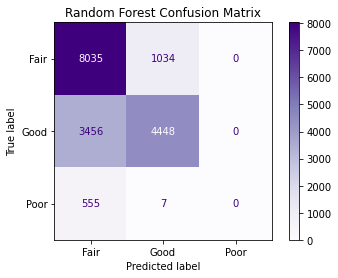

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix Random Forest. Build Confusion Matrix manually
rf_cm = rf_preds.groupBy("label", "prediction").count().toPandas()

# Create a 3x3 matrix initialized with zeros (for 3 classes: Fair=0, Good=1, Poor=2)
rf_matrix = np.zeros((3, 3), dtype=int)

# Fill the matrix
for row in rf_cm.itertuples(index=False):
    rf_matrix[int(row.label)][int(row.prediction)] = row.count

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=rf_matrix, display_labels=["Fair", "Good", "Poor"])
disp.plot(cmap='Purples')
plt.title("Random Forest Confusion Matrix")
plt.show()



In [0]:
# Accuracy per State for Random Forest
from pyspark.sql.functions import col, expr, round

# Attached State info to prediction
rf_preds_with_state = rf_preds.select("State_Name", "label", "prediction")

# Create a column for correct predictions
rf_preds_with_state = rf_preds_with_state.withColumn(
    "correct", (col("label") == col("prediction")).cast("int")
)
# Group by state and calculate accuracy
state_accuracy = rf_preds_with_state.groupBy("State_Name") \
    .agg(
        (expr("sum(correct) / count(*)")).alias("Accuracy")
    ).orderBy("accuracy", ascending=False)

state_accuracy.show(truncate=False)


+----------+------------------+
|State_Name|Accuracy          |
+----------+------------------+
|Virginia  |0.7678634909349449|
|New York  |0.7027183342972817|
|Texas     |0.7007279829545454|
+----------+------------------+



In [0]:
display(state_accuracy)

State_Name,Accuracy
Virginia,0.7678634909349449
New York,0.7027183342972817
Texas,0.7007279829545454


Databricks visualization. Run in Databricks to view.

Feature Importances:
Bridge_Age: 0.7953
Main_Span_Material_Index: 0.1561
Deck_Area_sqft: 0.0386
Average_Daily_Traffic: 0.0100


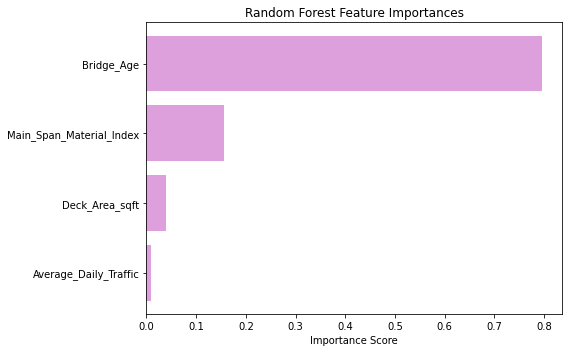

In [0]:
# 📊 Extract feature importances for Random Forest
importances = rf_model.featureImportances.toArray()
feature_importance = list(zip(features, importances))

# 🔽 Sort by importance (higest first)
sorted_importance = sorted(feature_importance, key=lambda x: x[1], reverse=True)

# 💬 Display in text
print("Feature Importances:")
for feature, score in sorted_importance:
    print(f"{feature}: {score:.4f}")

# 📉 Plot it
labels, scores = zip(*sorted_importance)
plt.figure(figsize=(8, 5))
plt.barh(labels, scores, color='plum')
plt.xlabel("Importance Score")
plt.title("Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [0]:
# NaiveBayes
from pyspark.ml.classification import NaiveBayes
nb = NaiveBayes(labelCol="label", featuresCol="features", modelType="multinomial")
nb_model = nb.fit(train_data)
nb_preds = nb_model.transform(test_data)


In [0]:
nb_preds.select("Bridge_Condition", "label", "prediction", "probability").show(truncate=False, n=nb_preds.count())


+----------------+-----+----------+-------------------------------------------------------------------+
|Bridge_Condition|label|prediction|probability                                                        |
+----------------+-----+----------+-------------------------------------------------------------------+
|Fair            |0.0  |2.0       |[0.0,0.0,1.0]                                                      |
|Good            |1.0  |0.0       |[1.0,0.0,0.0]                                                      |
|Fair            |0.0  |2.0       |[0.0,0.0,1.0]                                                      |
|Fair            |0.0  |2.0       |[0.0,0.0,1.0]                                                      |
|Good            |1.0  |2.0       |[0.0,0.0,1.0]                                                      |
|Fair            |0.0  |0.0       |[1.0,1.1579294572984234E-216,0.0]                                  |
|Good            |1.0  |0.0       |[1.0,1.2489853403091801E-24,5

In [0]:
# Group by actual label and predicted label and show the count of each pair (actual, predicted). Test to see how many times it is the correct prediction and how many times it is the inccorect predict.
nb_preds.groupBy("label", "prediction").count().orderBy("label", "prediction").show()

# model accuracy
nb_accuracy = evaluator.evaluate(nb_preds)
print ("NB accuracy", nb_accuracy)
# F1 score
nb_f1 = f1_evaluator.evaluate(nb_preds)
print("NB F1-score:", nb_f1)

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0| 3573|
|  0.0|       1.0|  267|
|  0.0|       2.0| 5229|
|  1.0|       0.0| 2884|
|  1.0|       1.0|  271|
|  1.0|       2.0| 4749|
|  2.0|       0.0|  133|
|  2.0|       1.0|   12|
|  2.0|       2.0|  417|
+-----+----------+-----+

NB accuracy 0.24299971485600227
NB F1-score: 0.2673602887274714


In [0]:
# to analyze F1 score per each condition Poor, Fair, Good
# Convert Spark DataFrame to Pandas
nb_preds_pd = nb_preds.select("label", "prediction").toPandas()

from sklearn.metrics import classification_report
print(classification_report(nb_preds_pd["label"], nb_preds_pd["prediction"], target_names=["Fair", "Good", "Poor"]))



              precision    recall  f1-score   support

        Fair       0.54      0.39      0.46      9069
        Good       0.49      0.03      0.06      7904
        Poor       0.04      0.74      0.08       562

    accuracy                           0.24     17535
   macro avg       0.36      0.39      0.20     17535
weighted avg       0.50      0.24      0.27     17535



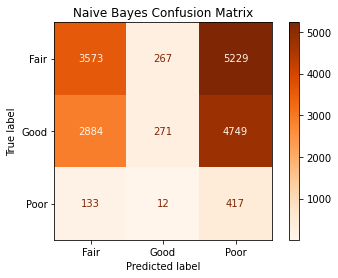

In [0]:
# Confusion Matrix Naive Bayes. Build Confusion Matrix manually
nb_cm = nb_preds.groupBy("label", "prediction").count().toPandas()

# Create a 3x3 matrix initialized with zeros (for 3 classes: Fair=0, Good=1, Poor=2)
nb_matrix = np.zeros((3, 3), dtype=int)

# Fill the matrix
for row in nb_cm.itertuples(index=False):
    nb_matrix[int(row.label)][int(row.prediction)] = row.count

# Display the confusion matrix
disp2 = ConfusionMatrixDisplay(confusion_matrix=nb_matrix, display_labels=["Fair", "Good", "Poor"])
disp2.plot(cmap='Oranges')
plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [0]:
# Accuracy per State for Naive Bayes
# Attached State info to prediction
nb_preds_with_state = nb_preds.select("State_Name", "label", "prediction")

# Create a column for correct predictions
nb_preds_with_state = nb_preds_with_state.withColumn(
    "correct", (col("label") == col("prediction")).cast("int")
)
# Group by state and calculate accuracy
nb_state_accuracy = nb_preds_with_state.groupBy("State_Name") \
    .agg(
        (expr("sum(correct) / count(*)")).alias("Accuracy")
    ).orderBy("accuracy", ascending=False)

nb_state_accuracy.show(truncate=False)

+----------+-------------------+
|State_Name|Accuracy           |
+----------+-------------------+
|New York  |0.29930595720069403|
|Virginia  |0.2943476715250622 |
|Texas     |0.212890625        |
+----------+-------------------+



In [0]:
display(nb_state_accuracy)

State_Name,Accuracy
New York,0.29930595720069403
Virginia,0.2943476715250622
Texas,0.212890625


Databricks visualization. Run in Databricks to view.

In [0]:
# Decision Tree
from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier(labelCol="label", featuresCol="features", seed=43)
dt_model = dt.fit(train_data)
dt_preds = dt_model.transform(test_data)


In [0]:
dt_preds.select("Bridge_Condition", "label", "prediction", "probability").show(truncate=False, n=nb_preds.count())

+----------------+-----+----------+--------------------------------------------------------------+
|Bridge_Condition|label|prediction|probability                                                   |
+----------------+-----+----------+--------------------------------------------------------------+
|Fair            |0.0  |0.0       |[0.7404570798357943,0.16101954537099442,0.0985233747932112]   |
|Good            |1.0  |1.0       |[0.11687015280657298,0.8823619749673655,7.678722260615834E-4] |
|Fair            |0.0  |0.0       |[0.7404570798357943,0.16101954537099442,0.0985233747932112]   |
|Fair            |0.0  |0.0       |[0.7404570798357943,0.16101954537099442,0.0985233747932112]   |
|Good            |1.0  |0.0       |[0.7404570798357943,0.16101954537099442,0.0985233747932112]   |
|Fair            |0.0  |0.0       |[0.7404570798357943,0.16101954537099442,0.0985233747932112]   |
|Good            |1.0  |0.0       |[0.7404570798357943,0.16101954537099442,0.0985233747932112]   |
|Poor     

In [0]:
# Group by actual label and predicted label and show the count of each pair (actual, predicted). Test to see how many times it is the correct prediction and how many times it is the inccorect predict.
dt_preds.groupBy("label", "prediction").count().orderBy("label", "prediction").show()

# model accuracy
dt_accuracy = evaluator.evaluate(dt_preds)
print("DT Accuracy", dt_accuracy)
# F1 score
dt_f1 = f1_evaluator.evaluate(dt_preds)
print("DT F1-score", dt_f1)

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0| 7927|
|  0.0|       1.0| 1142|
|  1.0|       0.0| 3292|
|  1.0|       1.0| 4612|
|  2.0|       0.0|  545|
|  2.0|       1.0|   17|
+-----+----------+-----+

DT Accuracy 0.7150841174793271
DT F1-score 0.6976286110874861


In [0]:
# to analyze F1 score per each condition Poor, Fair, Good
# Convert Spark DataFrame to Pandas
dt_preds_pd = dt_preds.select("label", "prediction").toPandas()

from sklearn.metrics import classification_report
print(classification_report(dt_preds_pd["label"], dt_preds_pd["prediction"], target_names=["Fair", "Good", "Poor"]))

              precision    recall  f1-score   support

        Fair       0.67      0.87      0.76      9069
        Good       0.80      0.58      0.67      7904
        Poor       0.00      0.00      0.00       562

    accuracy                           0.72     17535
   macro avg       0.49      0.49      0.48     17535
weighted avg       0.71      0.72      0.70     17535



/databricks/python/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/databricks/python/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/databricks/python/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


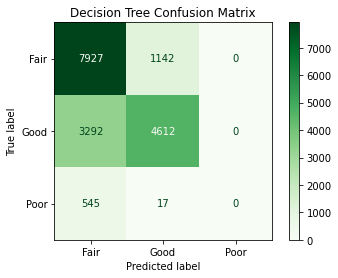

In [0]:
# Confusion Matrix Decision Tree. Build Confusion Matrix manually
dt_cm = dt_preds.groupBy("label", "prediction").count().toPandas()

# Create a 3x3 matrix initialized with zeros (for 3 classes: Fair=0, Good=1, Poor=2)
dt_matrix = np.zeros((3, 3), dtype=int)

# Fill the matrix
for row in dt_cm.itertuples(index=False):
    dt_matrix[int(row.label)][int(row.prediction)] = row.count

# Display the confusion matrix
disp1 = ConfusionMatrixDisplay(confusion_matrix=dt_matrix, display_labels=["Fair", "Good", "Poor"])
disp1.plot(cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [0]:
# Accuracy per State for Decision Tree
# Attached State info to prediction
dt_preds_with_state = dt_preds.select("State_Name", "label", "prediction")

# Create a column for correct predictions
dt_preds_with_state = dt_preds_with_state.withColumn(
    "correct", (col("label") == col("prediction")).cast("int")
)
# Group by state and calculate accuracy
dt_state_accuracy = dt_preds_with_state.groupBy("State_Name") \
    .agg(
        (expr("sum(correct) / count(*)")).alias("Accuracy")
    ).orderBy("accuracy", ascending=False)

dt_state_accuracy.show(truncate=False)

+----------+------------------+
|State_Name|Accuracy          |
+----------+------------------+
|Virginia  |0.7682189832918592|
|New York  |0.7058993637941007|
|Texas     |0.7046342329545454|
+----------+------------------+



In [0]:
display(dt_state_accuracy)

State_Name,Accuracy
Virginia,0.7682189832918592
New York,0.7058993637941007
Texas,0.7046342329545454


Databricks visualization. Run in Databricks to view.

Feature Importances:
Bridge_Age: 0.8594
Main_Span_Material_Index: 0.1156
Deck_Area_sqft: 0.0251
Average_Daily_Traffic: 0.0000


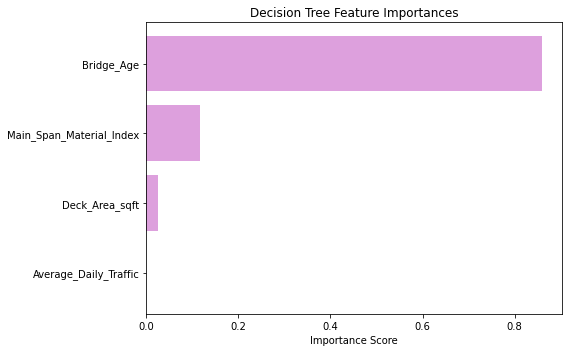

In [0]:
# 📊 Extract feature importances for Decision Tree
dt_importances = dt_model.featureImportances.toArray()
dt_feature_importance = list(zip(features, dt_importances))

# 🔽 Sort by importance 
dt_sorted_importance = sorted(dt_feature_importance, key=lambda x: x[1], reverse=True)

# 💬 Display in text
print("Feature Importances:")
for feature, score in dt_sorted_importance:
    print(f"{feature}: {score:.4f}")

# 📉 Plot it
labels, scores = zip(*dt_sorted_importance)
plt.figure(figsize=(8, 5))
plt.barh(labels, scores, color='plum')
plt.xlabel("Importance Score")
plt.title("Decision Tree Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [0]:
# Preprocessing data for KNN
# Convert Spark DataFrames to pandas
train_pd = train_data.select("label", "features").toPandas()
test_pd = test_data.select("label", "features").toPandas()

# Convert them to NumPy arrays
import numpy as np
X_train = np.array(train_pd["features"].tolist())
y_train = train_pd["label"]
X_test = np.array(test_pd["features"].tolist())
y_test = test_pd["label"]

# Standard scaler (subtract mean, divide by standard deviation). Avoid features like Deck Area or Average Daily Traffic dominated the learning, since they are much larger than Age
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


/databricks/spark/python/pyspark/sql/pandas/conversion.py:122: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  Unable to convert the field features. If this column is not necessary, you may consider dropping it or converting to primitive type before the conversion.
Direct cause: Unsupported type in conversion to Arrow: VectorUDT()
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
/databricks/spark/python/pyspark/sql/pandas/conversion.py:122: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  Unable to convert the field features. If this column is not necessary, you may consider dropping it or converting to primitive type before the conversion.
Direct cause: Unsupported type in conversion to Arrow: VectorUDT()
At

In [0]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
# Predict on test set - unseen data
y_pred = knn.predict(X_test_scaled)


In [0]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("KNN Accuracy:", accuracy)

# F1-score (macro = average for all classes)
f1 = f1_score(y_test, y_pred, average='macro')
print("KNN F1-score:", f1)

# classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Fair", "Good", "Poor"]))

KNN Accuracy: 0.6929569432563445
KNN F1-score: 0.49868937869528707

Classification Report:

              precision    recall  f1-score   support

        Fair       0.69      0.75      0.72      9069
        Good       0.71      0.67      0.69      7904
        Poor       0.29      0.05      0.09       562

    accuracy                           0.69     17535
   macro avg       0.56      0.49      0.50     17535
weighted avg       0.68      0.69      0.68     17535



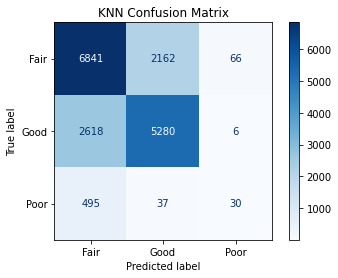

In [0]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict
y_pred = knn.predict(X_test_scaled)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fair", "Good", "Poor"])
disp.plot(cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.show()


In [0]:
# Get original test data with State_Name and label
state_info = test_data.select("State_Name", "label").toPandas()

# Add prediction column from KNN output
state_info["prediction"] = y_pred

# Add a column for correct predictions
state_info["correct"] = (state_info["label"] == state_info["prediction"]).astype(int)

# Group by state and calculate accuracy
kn_state_accuracy = state_info.groupby("State_Name")["correct"].mean().reset_index()
kn_state_accuracy = kn_state_accuracy.rename(columns={"correct": "Accuracy"})

# Sort by accuracy
kn_state_accuracy = kn_state_accuracy.sort_values(by="Accuracy", ascending=False)
print(kn_state_accuracy)


  State_Name  Accuracy
2   Virginia  0.699964
1      Texas  0.694336
0   New York  0.682765


In [0]:
display(kn_state_accuracy)

State_Name,Accuracy
Virginia,0.6999644507643086
Texas,0.6943359375
New York,0.6827646038172354


Databricks visualization. Run in Databricks to view.

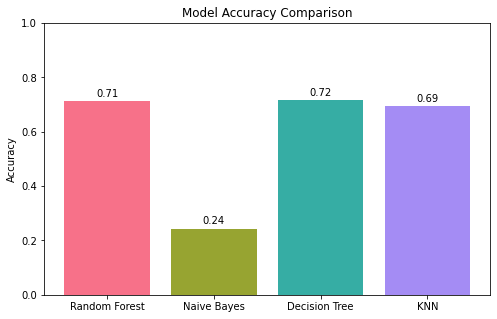

In [0]:
import seaborn as sns
# Plot Model Accuracy
# Accuracy values
accuracies = [rf_accuracy, nb_accuracy, dt_accuracy, accuracy]
models = ['Random Forest', 'Naive Bayes', 'Decision Tree', 'KNN']
palette = sns.color_palette("husl", 4)

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=palette)
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')

# Add accuracy values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom')

plt.show()


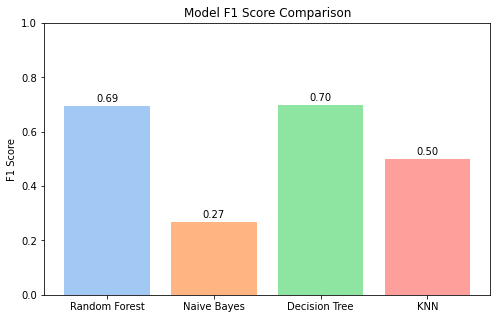

In [0]:
# Plot F1 scores
models = ['Random Forest', 'Naive Bayes', 'Decision Tree', 'KNN']
f1_scores = [rf_f1, nb_f1, dt_f1, f1]  

# Set pastel palette
palette = sns.color_palette("pastel", len(models))

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(models, f1_scores, color=palette)
plt.ylim(0, 1)
plt.ylabel('F1 Score')
plt.title('Model F1 Score Comparison')

# Add value labels on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom')

plt.show()


In [0]:
# Perform Material Accuracy for Random Forest
from pyspark.sql.functions import col, expr

# Add column to flag correct predictions
rf_preds_with_mat = rf_preds.withColumn(
    "correct", (col("label") == col("prediction")).cast("int")
)

# Group by material and compute accuracy
rf_mat_accuracy = rf_preds_with_mat.groupBy("Main_Span_Material") \
    .agg(expr("sum(correct) / count(*)").alias("Accuracy")) \
    .orderBy("accuracy", ascending=False)

rf_mat_accuracy.show(truncate=False)


+-----------------------------------------------------------+------------------+
|Main_Span_Material                                         |Accuracy          |
+-----------------------------------------------------------+------------------+
|Masonry                                                    |0.8666666666666667|
|Other Material Main Span OR No Approach or Second Span Type|0.8571428571428571|
|Steel Continuous                                           |0.7899917965545529|
|Concrete Continuous                                        |0.7672583826429981|
|Prestressed Concrete                                       |0.7357679914070892|
|Steel                                                      |0.717206132879046 |
|Prestressed Concrete Continuous                            |0.7131782945736435|
|Concrete                                                   |0.6766051865205935|
|Wood or Timber                                             |0.6744186046511628|
|Aluminum, Wrought Iron or C

In [0]:
# Perform Material Accuracy for Decision Tree
# Add column to flag correct predictions
dt_preds_with_mat = dt_preds.withColumn(
    "correct", (col("label") == col("prediction")).cast("int")
)

# Group by material and compute accuracy
dt_mat_accuracy = dt_preds_with_mat.groupBy("Main_Span_Material") \
    .agg(expr("sum(correct) / count(*)").alias("Accuracy")) \
    .orderBy("accuracy", ascending=False)

dt_mat_accuracy.show(truncate=False)

+-----------------------------------------------------------+------------------+
|Main_Span_Material                                         |Accuracy          |
+-----------------------------------------------------------+------------------+
|Masonry                                                    |0.8666666666666667|
|Other Material Main Span OR No Approach or Second Span Type|0.8571428571428571|
|Steel Continuous                                           |0.7908121410992617|
|Concrete Continuous                                        |0.7652859960552268|
|Prestressed Concrete                                       |0.7493018259935553|
|Steel                                                      |0.7166382737081204|
|Prestressed Concrete Continuous                            |0.7131782945736435|
|Concrete                                                   |0.6767438635418112|
|Wood or Timber                                             |0.6511627906976745|
|Aluminum, Wrought Iron or C

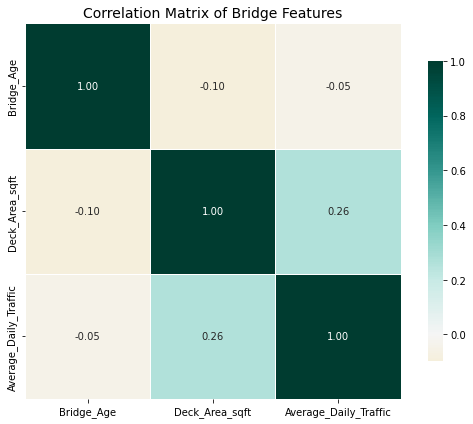

In [0]:
# Perform Correlation Matrix for Bridge Features
# Select numerical features only
numeric_df = df1.select("Bridge_Age", "Deck_Area_sqft", "Average_Daily_Traffic")

# Convert to Pandas
numeric_pd = numeric_df.toPandas()

# Compute correlation
import seaborn as sns
import matplotlib.pyplot as plt

corr = numeric_pd.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,                # show the actual numbers
    cmap="BrBG",               # color
    center=0,                  # center the color around 0
    fmt=".2f",                 # show 2 decimal places
    linewidths=0.5,            # gridlines for clarity
    square=True,               # square cells
    cbar_kws={"shrink": 0.8}   # adjust colorbar size
)
plt.title("Correlation Matrix of Bridge Features", fontsize=14)
plt.tight_layout()
plt.show()
